# EDA: детектор ботов по кукам

## 1. Загрузка и базовая проверка

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as sp_entropy, ks_2samp
from sklearn.metrics import roc_auc_score
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 100)

PAL = {0: "#4c72b0", 1: "#dd8452"}
ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data"
UA_BOT = r"headless|scrapy|curl|go-http-client|python-requests|python-urllib|node-fetch|\bbot\b|crawler|spider"
PLATFORM_MAP = {"web": "web", "desktop": "web", "android": "android", "ios": "ios", "iphone": "ios"}

In [ ]:
TS = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), parse_dates=TS)
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"), parse_dates=TS)
events = pd.read_csv(os.path.join(DATA_PATH, "events.csv"), parse_dates=["event_ts"])

print(f"train {train.shape} | test {test.shape} | events {events.shape}")
display(train.head())
display(test.head())
display(events.head())

train (11091, 5) | test (4909, 4) | events (328905, 14)


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [ ]:
print("Пересечение cookie_id train/test:", len(set(train.cookie_id) & set(test.cookie_id)))

for name, d in (("train", train), ("test", test)):
    print(f"{name}: строк {len(d)}, уникальных cookie_id {d['cookie_id'].nunique()}, "
          f"окно, ч: {sorted(((d.window_end_ts - d.window_start_ts).dt.total_seconds() / 3600).round(2).unique())}, "
          f"период {d.window_start_ts.min()} — {d.window_start_ts.max()}")

Пересечение cookie_id train/test: 0
train: строк 11091, уникальных cookie_id 11091, окно, ч: [np.float64(24.0)], период 2026-04-06 00:00:00 — 2026-04-19 00:00:00
test: строк 4909, уникальных cookie_id 4909, окно, ч: [np.float64(24.0)], период 2026-04-20 00:00:00 — 2026-04-26 00:00:00


## 2. Целевая переменная

Доля ботов: 0.0811


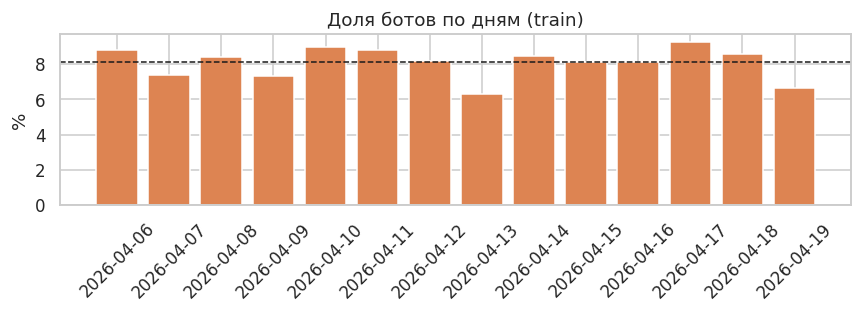

In [ ]:
print("Доля ботов:", train["target"].mean().round(4))

by_day = train.groupby(train.window_start_ts.dt.date)["target"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(by_day.index.astype(str), by_day["mean"] * 100, color=PAL[1])
ax.axhline(train.target.mean() * 100, ls="--", c="k", lw=1)
ax.set(title="Доля ботов по дням (train)", ylabel="%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Test идёт строго после train по времени — значит валидация должна быть по времени, а не случайным разбиением.

## 3. Предобработка событий

In [ ]:
print("Значения platform до маппинга:", events["platform"].str.lower().value_counts(dropna=False).to_dict())
plat_raw = events["platform"].str.lower()
events["platform"] = plat_raw.map(PLATFORM_MAP)

Значения platform до маппинга: {'web': 138792, 'android': 126875, 'desktop': 46866, 'ios': 12269, 'iphone': 4103}


In [ ]:
n0 = len(events)
events = events.drop_duplicates().reset_index(drop=True)
print(f"Полных дублей: {n0 - len(events)}")
print("eid == event_name (1:1):", (events.groupby("eid")["event_name"].nunique() == 1).all())

Полных дублей: 4868
eid == event_name (1:1): True


In [ ]:
print("Пропуски по типам событий (доля):")
display(events.groupby("event_name").apply(lambda g: g.isna().mean()).round(2))

Пропуски по типам событий (доля):


/tmp/ipykernel_58/346522223.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(events.groupby("event_name").apply(lambda g: g.isna().mean()).round(2))


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,,,,,,,
captcha_shown,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,1.00,1.00,1.0,1.0,0.73,0.73
contact_chat_open,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.08,1.0,1.0,0.69,0.69
contact_message_sent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.09,1.0,1.0,0.68,0.68
contact_phone_show,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.09,1.0,1.0,0.68,0.68
favorite_add,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.09,1.0,1.0,0.65,0.65
item_view,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.09,1.0,1.0,0.67,0.67
login,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.00,1.00,1.00,1.0,1.0,0.65,0.65
photo_swipe,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.03,0.09,1.0,1.0,0.66,0.66
search_results_view,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.06,0.03,1.00,0.0,0.0,0.67,0.67


## 4. События вне окна

Событие могло произойти до старта окна наблюдения или уже после его конца. Модель обучается на событиях внутри окна.

In [ ]:
meta = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
ev = events.merge(
    meta[["cookie_id", "window_start_ts", "window_end_ts", "split", "target"]], on="cookie_id", how="inner"
)
ev["position"] = np.select(
    [ev.event_ts < ev.window_start_ts, ev.event_ts >= ev.window_end_ts],
    ["before", "after"], default="in_window",
)
print("Положение событий относительно окна, доли по split:")
display(pd.crosstab(ev["split"], ev["position"], normalize="index").round(3))
display(pd.crosstab(ev["event_name"], ev["position"]))

Положение событий относительно окна, доли по split:


position,after,in_window
split,,
test,0.000,1.000
train,0.171,0.829


position,after,in_window
event_name,,
captcha_shown,7829,0
contact_chat_open,568,5479
contact_message_sent,254,2778
contact_phone_show,1009,10145
favorite_add,1727,17012
item_view,12542,106447
login,599,5578
photo_swipe,3392,32570
search_results_view,10450,88478


In [ ]:
ev = ev[ev.position == "in_window"].drop(columns="position").reset_index(drop=True)
print("Событий в окне:", len(ev))

Событий в окне: 283830


Дальше и EDA, и признаки строятся только по событиям внутри окна.

## 5. Сборка признаков

In [ ]:
def hist_entropy(s, bins, rng):
    s = s.dropna()
    if len(s) < 2:
        return np.nan
    h, _ = np.histogram(s, bins=bins, range=rng)
    return float(sp_entropy(h)) if h.sum() else np.nan


def build_features(meta_df, ev_df):
    ev_df = ev_df.copy()

    # User-Agent разбираем один раз по уникальным строкам, затем протягиваем на события
    uas = pd.DataFrame({"user_agent": ev_df["user_agent"].dropna().unique()})
    low = uas["user_agent"].str.lower()
    uas["is_bot_ua"] = low.str.contains(UA_BOT, regex=True)
    uas["is_app"] = low.str.startswith("avito/")
    uas["is_mobile"] = low.str.contains("android|iphone|ipad", regex=True)
    uas["chrome_v"] = uas["user_agent"].str.extract(r"Chrome/(\d+)")[0].astype(float)
    uas["android_v"] = uas["user_agent"].str.extract(r"Android (\d+)")[0].astype(float)
    uas["ios_v"] = uas["user_agent"].str.extract(r"OS (\d+)_")[0].astype(float)
    uas["ua_os"] = np.select(
        [uas.is_app, low.str.contains("android"), low.str.contains("iphone|ipad|ios", regex=True),
         low.str.contains("windows"), low.str.contains("mac os"), low.str.contains("linux")],
        ["app", "android", "ios", "windows", "macos", "linux"], default="other")
    uas["ua_browser"] = np.select(
        [uas.is_bot_ua, uas.is_app, low.str.contains("firefox"), low.str.contains("edg/"),
         low.str.contains("chrome"), low.str.contains("safari")],
        ["script", "app", "firefox", "edge", "chrome", "safari"], default="other")
    ev_df = ev_df.merge(uas, on="user_agent", how="left")

    ev_df = ev_df.sort_values(["cookie_id", "event_ts"]).reset_index(drop=True)
    ev_df["gap_s"] = ev_df.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()
    g = ev_df.groupby("cookie_id")

    # объём и ритм
    f = pd.DataFrame({"n_events": g.size(), "n_event_types": g["event_name"].nunique()})
    f["span_min"] = (g["event_ts"].max() - g["event_ts"].min()).dt.total_seconds() / 60
    f["gap_median"] = g["gap_s"].median()
    f["gap_cv"] = g["gap_s"].std() / g["gap_s"].mean().replace(0, np.nan)
    f["burst_share"] = (ev_df["gap_s"] <= 1).where(ev_df["gap_s"].notna()).groupby(ev_df["cookie_id"]).mean()
    f["peak_per_min"] = ev_df.groupby(["cookie_id", ev_df["event_ts"].dt.floor("min")]).size().groupby("cookie_id").max()
    f["night_share"] = ev_df["event_ts"].dt.hour.between(0, 5).groupby(ev_df["cookie_id"]).mean()
    f = f.join(pd.crosstab(ev_df["cookie_id"], ev_df["event_name"], normalize="index").add_prefix("share_"))

    # поиск
    s = ev_df[ev_df.event_name == "search_results_view"].groupby("cookie_id").agg(
        n_search=("event_ts", "size"), max_page=("search_page", "max"), n_queries=("search_query", "nunique"))
    s["queries_per_search"] = s["n_queries"] / s["n_search"]

    # просмотры
    v_ev = ev_df[ev_df.event_name == "item_view"]
    v = v_ev.groupby("cookie_id").agg(
        n_views=("event_ts", "size"), n_items=("item_id", "nunique"),
        n_categories=("item_category", "nunique"), n_locations=("item_location", "nunique"))
    v["repeat_views"] = 1 - v["n_items"] / v["n_views"]
    cat = v_ev.groupby(["cookie_id", "item_category"]).size()
    v["top_cat_share"] = cat.groupby(level=0).max() / cat.groupby(level=0).sum()

    # курсор (только web)
    web_n = ev_df[ev_df.platform == "web"].groupby("cookie_id").size()
    p = ev_df[ev_df.pointer_x.notna()].copy()
    pg = p.groupby("cookie_id")
    p["dx"], p["dy"] = pg["pointer_x"].diff(), pg["pointer_y"].diff()
    p["step"] = np.hypot(p.dx, p.dy)
    p["angle"] = np.arctan2(p.dy, p.dx)
    p["still"] = (p["step"] == 0).astype(float).where(p["step"].notna())
    lo, hi = p["dx"].quantile([0.01, 0.99]) if len(p) else (-1, 1)
    pg = p.groupby("cookie_id")
    ptr = pd.DataFrame({
        "ptr_n": pg.size(),
        "ptr_x_std": pg["pointer_x"].std(), "ptr_y_std": pg["pointer_y"].std(),
        "step_mean": pg["step"].mean(), "step_std": pg["step"].std(),
        "still_share": pg["still"].mean(),
        "entropy_dx": pg["dx"].apply(lambda x: hist_entropy(x, 20, (lo, hi))),
        "entropy_angle": pg["angle"].apply(lambda x: hist_entropy(x, 20, (-np.pi, np.pi))),
    })
    ptr["ptr_share"] = ptr["ptr_n"] / web_n.reindex(ptr.index)

    # UA / платформа на уровне куки
    cnt = ev_df.groupby(["cookie_id", "user_agent"]).size()
    pr = cnt / cnt.groupby(level=0).transform("sum")
    ua = pd.DataFrame({
        "n_ua": g["user_agent"].nunique(),
        "ua_entropy": -(pr * np.log(pr)).groupby(level=0).sum(),
        "bot_ua_share": g["is_bot_ua"].mean(), "mobile_share": g["is_mobile"].mean(),
        "chrome_ver": g["chrome_v"].median(), "android_ver": g["android_v"].median(), "ios_ver": g["ios_v"].median(),
    })
    mode = lambda x: x.mode().iloc[0] if x.notna().any() else np.nan
    cats = pd.DataFrame({
        "ua_browser": g["ua_browser"].agg(mode), "ua_os": g["ua_os"].agg(mode), "platform": g["platform"].agg(mode),
    })

    out = meta_df.set_index("cookie_id").join([f, s, v, ptr, ua, cats])
    out["n_events"] = out["n_events"].fillna(0)
    out["cookie_age_h"] = (out.window_start_ts - out.cookie_created_at).dt.total_seconds() / 3600
    out["start_hour"] = out.window_start_ts.dt.hour
    out["start_dow"] = out.window_start_ts.dt.dayofweek
    return out

In [ ]:
feats = build_features(meta, ev)
tr = feats[feats.split == "train"].copy()
te = feats[feats.split == "test"].copy()
print("Куки без событий в окне: train", (tr.n_events == 0).sum(), "| test", (te.n_events == 0).sum())

CAT = ["ua_browser", "ua_os", "platform"]
NUM = [c for c in feats.select_dtypes("number").columns if c != "target"]

Куки без событий в окне: train 0 | test 0


## 6. Важность признаков

ROC-AUC каждого признака относительно target (0.5 = признак не разделяет классы).

In [ ]:
def uni_auc(df, cols):
    rows = []
    for c in cols:
        d = df[[c, "target"]].dropna()
        if d["target"].nunique() < 2 or d[c].nunique() < 2:
            continue
        rows.append((c, roc_auc_score(d["target"], d[c]), len(d) / len(df)))
    res = pd.DataFrame(rows, columns=["feature", "auc", "coverage"])
    return res.assign(strength=(res.auc - 0.5).abs()).sort_values("strength", ascending=False)

auc_tab = uni_auc(tr, NUM)
display(auc_tab.head(20).round(3))

,feature,auc,coverage,strength
27,ptr_x_std,0.064,0.354,0.436
29,step_mean,0.068,0.354,0.432
30,step_std,0.097,0.338,0.403
28,ptr_y_std,0.194,0.354,0.306
3,gap_median,0.273,0.977,0.227
17,max_page,0.708,0.917,0.208
19,queries_per_search,0.294,0.917,0.206
23,n_locations,0.697,0.934,0.197
5,peak_per_min,0.693,1.000,0.193
21,n_items,0.676,0.934,0.176


## 7. Распределения признаков по классам

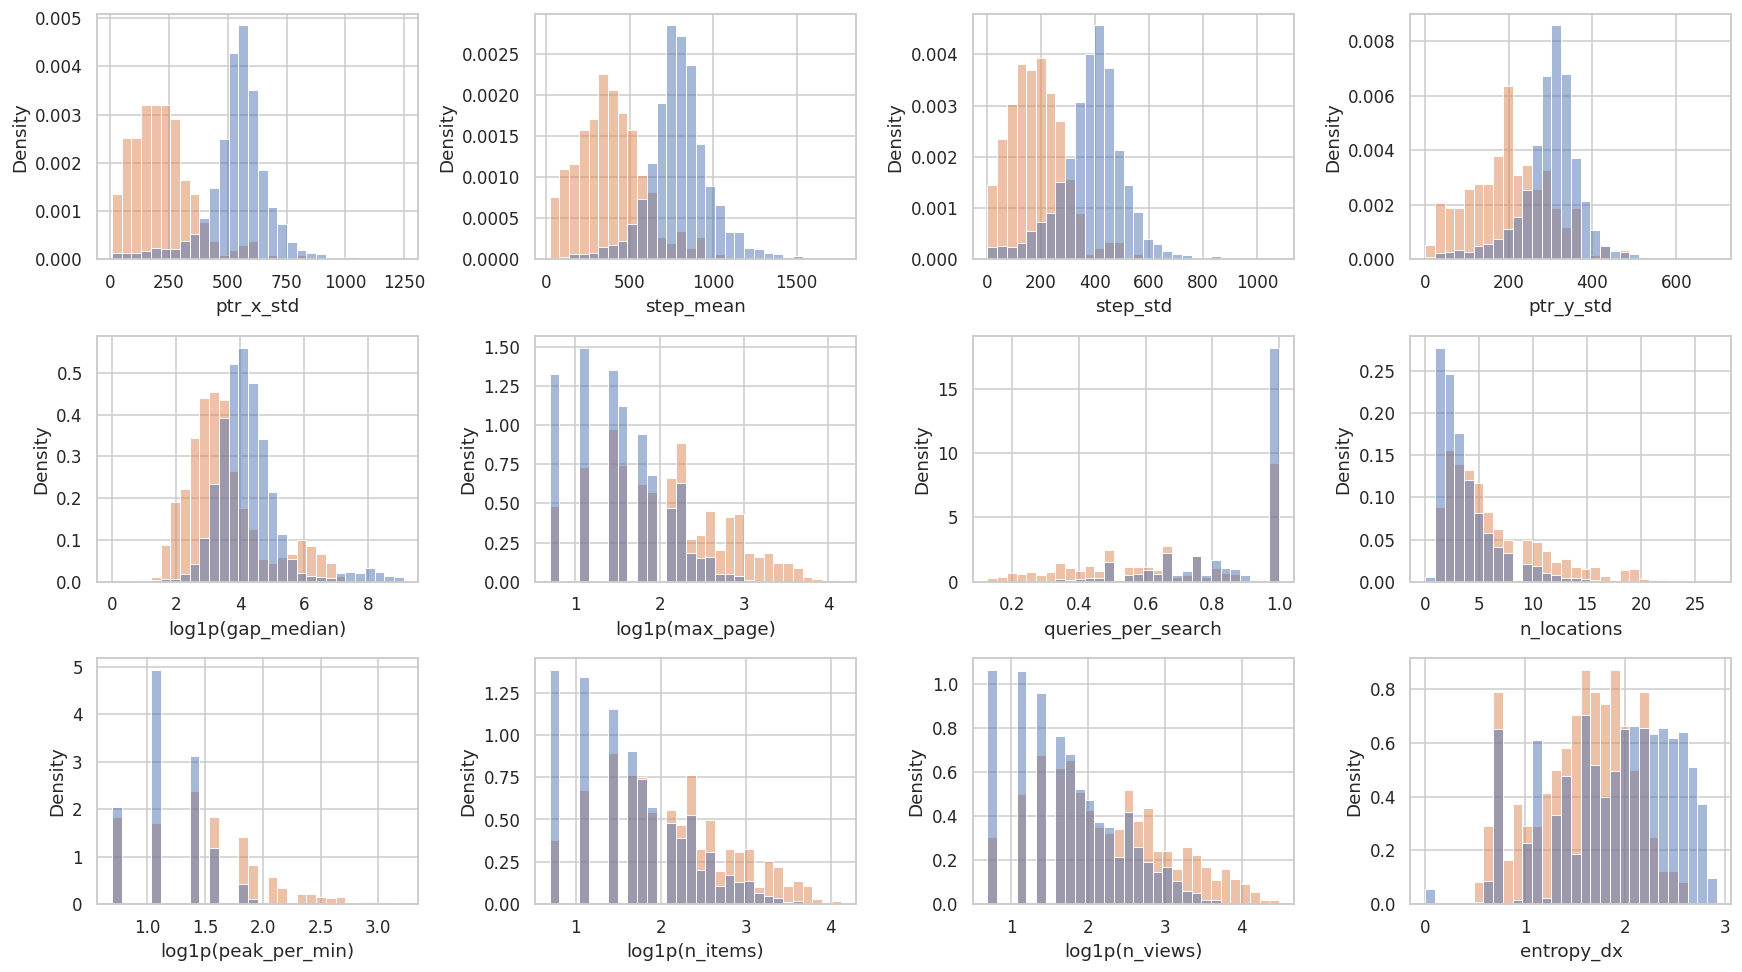

In [ ]:
top = auc_tab.feature.head(12).tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), top):
    x = tr[c]
    if x.min() >= 0 and x.skew() > 2:
        x, lbl = np.log1p(x), f"log1p({c})"
    else:
        lbl = c
    sns.histplot(x=x, hue=tr["target"], bins=30, stat="density", common_norm=False,
                 palette=PAL, ax=ax, legend=False)
    ax.set_xlabel(lbl)
plt.tight_layout()
plt.show()

## 8. Категориальные признаки и пропуски

In [ ]:
for c in CAT:
    display(tr.groupby(c, dropna=False)["target"].agg(cookies="size", bot_share="mean").round(3)
            .sort_values("bot_share"))

,cookies,bot_share
ua_browser,,
safari,192,0.047
chrome,6899,0.066
firefox,1373,0.087
app,2141,0.092
script,486,0.245


,cookies,bot_share
ua_os,,
android,2841,0.037
ios,192,0.047
macos,1348,0.082
windows,4083,0.088
app,2141,0.092
other,200,0.220
linux,286,0.262


,cookies,bot_share
platform,,
ios,579,0.045
android,4595,0.062
web,5917,0.099


In [ ]:
miss = tr[NUM].isna().groupby(tr["target"]).mean().T
miss = miss[(miss > 0).any(axis=1)]
miss["diff"] = (miss[1] - miss[0]).abs()
print("Доля NaN по классам:")
display(miss.sort_values("diff", ascending=False).head(10).round(2))

Доля NaN по классам:


target,0.0,1.0,diff
android_ver,0.58,0.68,0.11
ptr_n,0.63,0.72,0.09
ptr_share,0.63,0.72,0.09
step_mean,0.64,0.72,0.08
still_share,0.64,0.72,0.08
ptr_y_std,0.64,0.72,0.08
ptr_x_std,0.64,0.72,0.08
step_std,0.66,0.72,0.07
entropy_angle,0.66,0.72,0.07
entropy_dx,0.66,0.72,0.07


## 9. Профиль активности: часы и состав событий

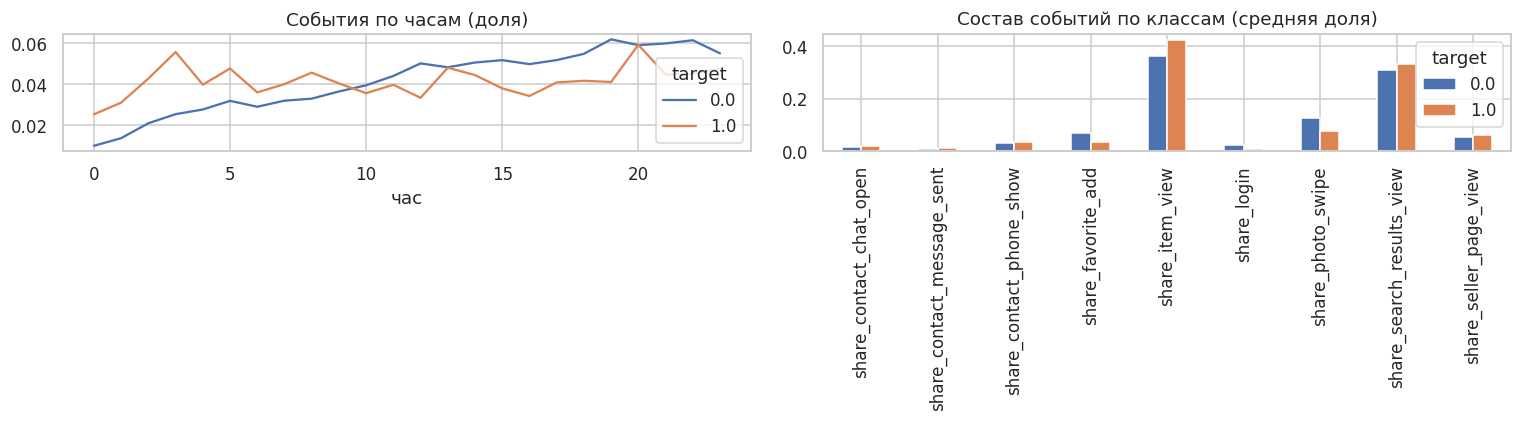

In [ ]:
hour = ev[ev.split == "train"].groupby([ev.event_ts.dt.hour, "target"]).size().unstack(fill_value=0)
mix = tr.groupby("target")[[c for c in NUM if c.startswith("share_")]].mean().T

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
(hour / hour.sum()).plot(ax=axes[0], color=PAL)
axes[0].set(title="События по часам (доля)", xlabel="час")
mix.plot(kind="bar", ax=axes[1], color=PAL)
axes[1].set_title("Состав событий по классам (средняя доля)")
plt.tight_layout()
plt.show()

## 10. Объём событий: выбросы

In [ ]:
bucket = pd.cut(tr.n_events, [-1, 0, 3, 6, 12, 25, 50, 10**6])
display(tr.groupby(bucket, observed=True)["target"].agg(cookies="size", bot_share="mean").round(3))

q99 = tr.n_events.quantile(0.99)
hi_ = tr[tr.n_events > q99]
print(f"Верхний 1% по n_events (> {q99:.0f}): кук {len(hi_)}, доля ботов {hi_.target.mean():.3f}")

,cookies,bot_share
n_events,,
"(0, 3]",1187,0.021
"(3, 6]",1719,0.048
"(6, 12]",2854,0.060
"(12, 25]",2989,0.087
"(25, 50]",1726,0.123
"(50, 1000000]",616,0.239


Верхний 1% по n_events (> 86): кук 108, доля ботов 0.417


## 11. Матрица корреляции

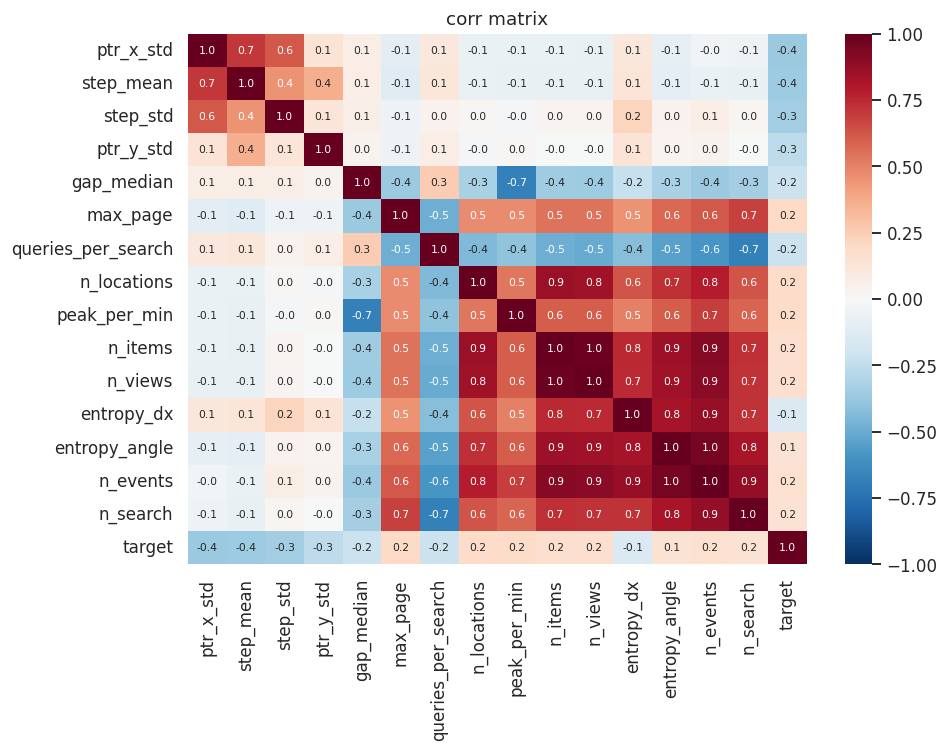

In [ ]:
cols = auc_tab.feature.head(15).tolist()
plt.figure(figsize=(9, 7))
sns.heatmap(tr[cols + ["target"]].corr(method="spearman"), cmap="RdBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("corr matrix")
plt.tight_layout()
plt.show()

## 12. Сдвиг train → test

Test — это следующие после train даты, поэтому важно понять, какие признаки за это время успели сместиться (KS-статистика по каждому).

In [ ]:
rows = []
for c in NUM:
    a, b = tr[c].dropna(), te[c].dropna()
    if len(a) > 10 and len(b) > 10:
        rows.append((c, ks_2samp(a, b).statistic))
shift = pd.DataFrame(rows, columns=["feature", "ks"]).sort_values("ks", ascending=False)
print("Наибольший сдвиг train vs test (KS-статистика):")
display(shift.head(10).round(3))

Наибольший сдвиг train vs test (KS-статистика):


,feature,ks
44,start_dow,0.062
27,ptr_x_std,0.046
41,ios_ver,0.045
29,step_mean,0.041
30,step_std,0.036
32,entropy_dx,0.026
17,max_page,0.026
28,ptr_y_std,0.023
34,ptr_share,0.022
25,top_cat_share,0.021


## Итог

- После конца окна в train встречаются события (в т.ч. `captcha_shown`) — их нужно отбрасывать, иначе модель обучится на утечке.
- Признаки собраны одной функцией `build_features`, которая одинаково применяется к train и test — это снимает риск рассинхронизации колонок между выборками.
- Сила признаков оценена через ROC-AUC, а не только через сравнение медиан — это сразу показывает, какие признаки стоит брать в модель.
- Отдельно проверен сдвиг распределений train → test — часть признаков может требовать time-aware валидации.